# Weather Data Analysis (Canada-2012 )

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv(r'E:\weather_dataset\1. Weather_Data.csv')

In [6]:
data.head()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog


In [10]:
data.shape

(8784, 8)

In [13]:
data.columns

Index(['Date/Time', 'Temp_C', 'Dew Point Temp_C', 'Rel Hum_%',
       'Wind Speed_km/h', 'Visibility_km', 'Press_kPa', 'Weather'],
      dtype='object')

In [15]:
data.nunique()

Date/Time           8784
Temp_C               533
Dew Point Temp_C     489
Rel Hum_%             83
Wind Speed_km/h       34
Visibility_km         24
Press_kPa            518
Weather               50
dtype: int64

In [16]:
# Count the not null values
data.count()

Date/Time           8784
Temp_C              8784
Dew Point Temp_C    8784
Rel Hum_%           8784
Wind Speed_km/h     8784
Visibility_km       8784
Press_kPa           8784
Weather             8784
dtype: int64

In [20]:
data['Weather'].value_counts()

Weather
Mainly Clear                               2106
Mostly Cloudy                              2069
Cloudy                                     1728
Clear                                      1326
Snow                                        390
Rain                                        306
Rain Showers                                188
Fog                                         150
Rain,Fog                                    116
Drizzle,Fog                                  80
Snow Showers                                 60
Drizzle                                      41
Snow,Fog                                     37
Snow,Blowing Snow                            19
Rain,Snow                                    18
Thunderstorms,Rain Showers                   16
Haze                                         16
Drizzle,Snow,Fog                             15
Freezing Rain                                14
Freezing Drizzle,Snow                        11
Freezing Drizzle                

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date/Time         8784 non-null   object 
 1   Temp_C            8784 non-null   float64
 2   Dew Point Temp_C  8784 non-null   float64
 3   Rel Hum_%         8784 non-null   int64  
 4   Wind Speed_km/h   8784 non-null   int64  
 5   Visibility_km     8784 non-null   float64
 6   Press_kPa         8784 non-null   float64
 7   Weather           8784 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 549.1+ KB


In [24]:
# Find all the unique 'wind speed' values in the data
data['Wind Speed_km/h'].nunique()

34

In [25]:
data['Wind Speed_km/h'].unique()

array([ 4,  7,  6,  9, 15, 13, 20, 22, 19, 24, 30, 35, 39, 32, 33, 26, 44,
       43, 48, 37, 28, 17, 11,  0, 83, 70, 57, 46, 41, 52, 50, 63, 54,  2])

#### The number of times when the 'Weather is exactly Clear'

In [33]:
data['Weather'][data['Weather'] == 'Clear'].count()

np.int64(1326)

In [34]:
data.groupby('Weather').get_group('Clear')

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
67,1/3/2012 19:00,-16.9,-24.8,50,24,25.0,101.74,Clear
114,1/5/2012 18:00,-7.1,-14.4,56,11,25.0,100.71,Clear
115,1/5/2012 19:00,-9.2,-15.4,61,7,25.0,100.80,Clear
116,1/5/2012 20:00,-9.8,-15.7,62,9,25.0,100.83,Clear
117,1/5/2012 21:00,-9.0,-14.8,63,13,25.0,100.83,Clear
...,...,...,...,...,...,...,...,...
8646,12/26/2012 6:00,-13.4,-14.8,89,4,25.0,102.47,Clear
8698,12/28/2012 10:00,-6.1,-8.6,82,19,24.1,101.27,Clear
8713,12/29/2012 1:00,-11.9,-13.6,87,11,25.0,101.31,Clear
8714,12/29/2012 2:00,-11.8,-13.1,90,13,25.0,101.33,Clear


In [42]:
# Find the null values in the data
data.isnull().sum()

Date/Time           0
Temp_C              0
Dew Point Temp_C    0
Rel Hum_%           0
Wind Speed_km/h     0
Visibility_km       0
Press_kPa           0
Weather             0
dtype: int64

In [47]:
# Visibility
data['Visibility_km'].mean()

np.float64(27.664446721311478)

In [49]:
# Standard Dviation of 'Pressure'
data['Press_kPa'].std()

0.8440047459486474

In [52]:
#variance of 'Relative Humidity'
data['Rel Hum_%'].var()

286.2485501984998

#### All the instances when 'Snow' was recorded

In [71]:
data[data['Weather'].str.contains('Snow')]

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
41,1/2/2012 17:00,-2.1,-9.5,57,22,25.0,99.66,Snow Showers
44,1/2/2012 20:00,-5.6,-13.4,54,24,25.0,100.07,Snow Showers
45,1/2/2012 21:00,-5.8,-12.8,58,26,25.0,100.15,Snow Showers
47,1/2/2012 23:00,-7.4,-14.1,59,17,19.3,100.27,Snow Showers
48,1/3/2012 0:00,-9.0,-16.0,57,28,25.0,100.35,Snow Showers
...,...,...,...,...,...,...,...,...
8779,12/31/2012 19:00,0.1,-2.7,81,30,9.7,100.13,Snow
8780,12/31/2012 20:00,0.2,-2.4,83,24,9.7,100.03,Snow
8781,12/31/2012 21:00,-0.5,-1.5,93,28,4.8,99.95,Snow
8782,12/31/2012 22:00,-0.2,-1.8,89,28,9.7,99.91,Snow


In [74]:
# All the instances when 'Wind speed is above 24' and 'Visibility' is 25
data[(data['Wind Speed_km/h']>24) & (data['Visibility_km'] == 25)]

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
23,1/1/2012 23:00,5.3,2.0,79,30,25.0,99.31,Cloudy
24,1/2/2012 0:00,5.2,1.5,77,35,25.0,99.26,Rain Showers
25,1/2/2012 1:00,4.6,0.0,72,39,25.0,99.26,Cloudy
26,1/2/2012 2:00,3.9,-0.9,71,32,25.0,99.26,Mostly Cloudy
27,1/2/2012 3:00,3.7,-1.5,69,33,25.0,99.30,Mostly Cloudy
...,...,...,...,...,...,...,...,...
8705,12/28/2012 17:00,-8.6,-12.0,76,26,25.0,101.34,Mainly Clear
8753,12/30/2012 17:00,-12.1,-15.8,74,28,25.0,101.26,Mainly Clear
8755,12/30/2012 19:00,-13.4,-16.5,77,26,25.0,101.47,Mainly Clear
8759,12/30/2012 23:00,-12.1,-15.1,78,28,25.0,101.52,Mostly Cloudy


In [81]:
# Mean value of each column against each 'Weather condition'
data.groupby('Weather').mean(['Temp_C','Dew Point Temp_C','Rel Hum_%','Wind Speed_km/h','Visibility_km','Press_kPa'])

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
Weather,,,,,,
Clear,6.825716,0.089367,64.497738,10.557315,30.153243,101.587443
Cloudy,7.970544,2.375810,69.592593,16.127315,26.625752,100.911441
Drizzle,7.353659,5.504878,88.243902,16.097561,17.931707,100.435366
"Drizzle,Fog",8.067500,7.033750,93.275000,11.862500,5.257500,100.786625
"Drizzle,Ice Pellets,Fog",0.400000,-0.700000,92.000000,20.000000,4.000000,100.790000
"Drizzle,Snow",1.050000,0.150000,93.500000,14.000000,10.500000,100.890000
"Drizzle,Snow,Fog",0.693333,0.120000,95.866667,15.533333,5.513333,99.281333
Fog,4.303333,3.159333,92.286667,7.946667,6.248000,101.184067
Freezing Drizzle,-5.657143,-8.000000,83.571429,16.571429,9.200000,100.202857


In [79]:
# Max value of each column against each 'Weather condition'
data.groupby('Weather').max(['Temp_C','Dew Point Temp_C','Rel Hum_%','Wind Speed_km/h','Visibility_km','Press_kPa'])

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
Weather,,,,,,
Clear,32.8,20.4,99,33,48.3,103.63
Cloudy,30.5,22.6,99,54,48.3,103.65
Drizzle,18.8,17.7,96,30,25.0,101.56
"Drizzle,Fog",19.9,19.1,100,28,9.7,102.07
"Drizzle,Ice Pellets,Fog",0.4,-0.7,92,20,4.0,100.79
"Drizzle,Snow",1.2,0.2,95,19,11.3,101.15
"Drizzle,Snow,Fog",1.1,0.6,98,32,9.7,100.15
Fog,20.8,19.6,100,22,9.7,103.04
Freezing Drizzle,-2.3,-3.3,93,26,12.9,101.02


In [82]:
# Min value of each column against each 'Weather condition'
data.groupby('Weather').min(['Temp_C','Dew Point Temp_C','Rel Hum_%','Wind Speed_km/h','Visibility_km','Press_kPa'])

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
Weather,,,,,,
Clear,-23.3,-28.5,20,0,11.3,99.52
Cloudy,-21.4,-26.8,18,0,11.3,98.39
Drizzle,1.1,-0.2,74,0,6.4,97.84
"Drizzle,Fog",0.0,-1.6,85,0,1.0,98.65
"Drizzle,Ice Pellets,Fog",0.4,-0.7,92,20,4.0,100.79
"Drizzle,Snow",0.9,0.1,92,9,9.7,100.63
"Drizzle,Snow,Fog",0.3,-0.1,92,7,2.4,97.79
Fog,-16.0,-17.2,80,0,0.2,98.31
Freezing Drizzle,-9.0,-12.2,78,6,4.8,98.44


#### All the records when Weather is fog

In [84]:
data[data['Weather'].str.contains('Fog')]

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog
...,...,...,...,...,...,...,...,...
8739,12/30/2012 3:00,-9.1,-10.4,90,11,3.6,100.30,"Snow,Fog"
8740,12/30/2012 4:00,-9.3,-10.6,90,13,9.7,100.28,"Snow,Fog"
8741,12/30/2012 5:00,-9.1,-10.4,90,11,4.0,100.32,"Snow,Fog"
8742,12/30/2012 6:00,-9.3,-10.8,89,17,8.0,100.39,"Snow,Fog"


#### All the instances when 'Weather recorded clear' and 'Visibility is above 40'

In [95]:
data[(data['Weather'].str.contains('Clear', na=False)) & (data['Visibility_km'] > 40)]

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
106,1/5/2012 10:00,-6.0,-10.0,73,17,48.3,100.45,Mainly Clear
107,1/5/2012 11:00,-5.6,-10.2,70,22,48.3,100.41,Mainly Clear
108,1/5/2012 12:00,-4.7,-9.6,69,20,48.3,100.38,Mainly Clear
109,1/5/2012 13:00,-4.4,-9.7,66,26,48.3,100.40,Mainly Clear
110,1/5/2012 14:00,-5.1,-10.7,65,22,48.3,100.46,Mainly Clear
...,...,...,...,...,...,...,...,...
8703,12/28/2012 15:00,-6.8,-10.3,76,24,48.3,101.22,Mainly Clear
8704,12/28/2012 16:00,-7.7,-11.0,77,30,48.3,101.25,Mainly Clear
8750,12/30/2012 14:00,-11.8,-16.1,70,37,48.3,100.96,Mainly Clear
8751,12/30/2012 15:00,-11.3,-15.6,70,32,48.3,101.05,Mainly Clear


#### Instances when A: 'Weather is clear' and relative Humidity is greater than 50 or B: 'visibility is above 40'

In [25]:
data[((data['Weather'] == 'Clear') & (data['Rel Hum_%']>50)) | (data['Visibility_km']>50)]

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather,Month,Hour
114,2012-01-05 18:00:00,-7.1,-14.4,56,11,25.0,100.71,Clear,January,18
115,2012-01-05 19:00:00,-9.2,-15.4,61,7,25.0,100.80,Clear,January,19
116,2012-01-05 20:00:00,-9.8,-15.7,62,9,25.0,100.83,Clear,January,20
117,2012-01-05 21:00:00,-9.0,-14.8,63,13,25.0,100.83,Clear,January,21
241,2012-01-11 01:00:00,-10.7,-17.8,56,17,25.0,101.49,Clear,January,1
...,...,...,...,...,...,...,...,...,...,...
8646,2012-12-26 06:00:00,-13.4,-14.8,89,4,25.0,102.47,Clear,December,6
8698,2012-12-28 10:00:00,-6.1,-8.6,82,19,24.1,101.27,Clear,December,10
8713,2012-12-29 01:00:00,-11.9,-13.6,87,11,25.0,101.31,Clear,December,1
8714,2012-12-29 02:00:00,-11.8,-13.1,90,13,25.0,101.33,Clear,December,2


#### Monthly Average Temperature Trend

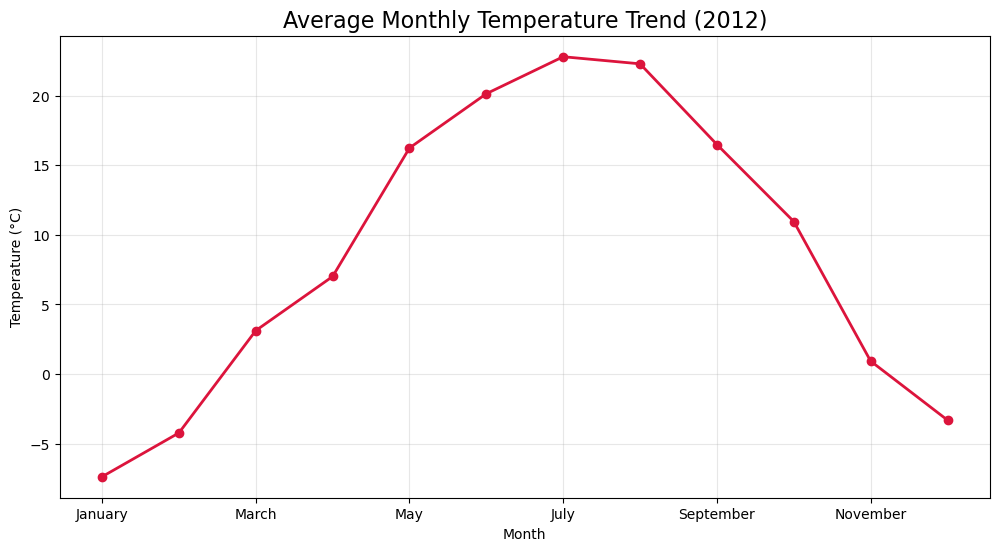

In [4]:
data['Date/Time'] = pd.to_datetime(data['Date/Time'])
data['Month'] = data['Date/Time'].dt.month_name()
monthly_avg = data.groupby('Month')['Temp_C'].mean().reindex(['January','February','March','April','May','June',
    'July','August','September','October','November','December'])
plt.figure(figsize=(12,6))
monthly_avg.plot(kind='line', marker='o', color='crimson', linewidth=2)
plt.title('Average Monthly Temperature Trend (2012)', fontsize=16)
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.show()

#### Relationship between Temperature & Humidity

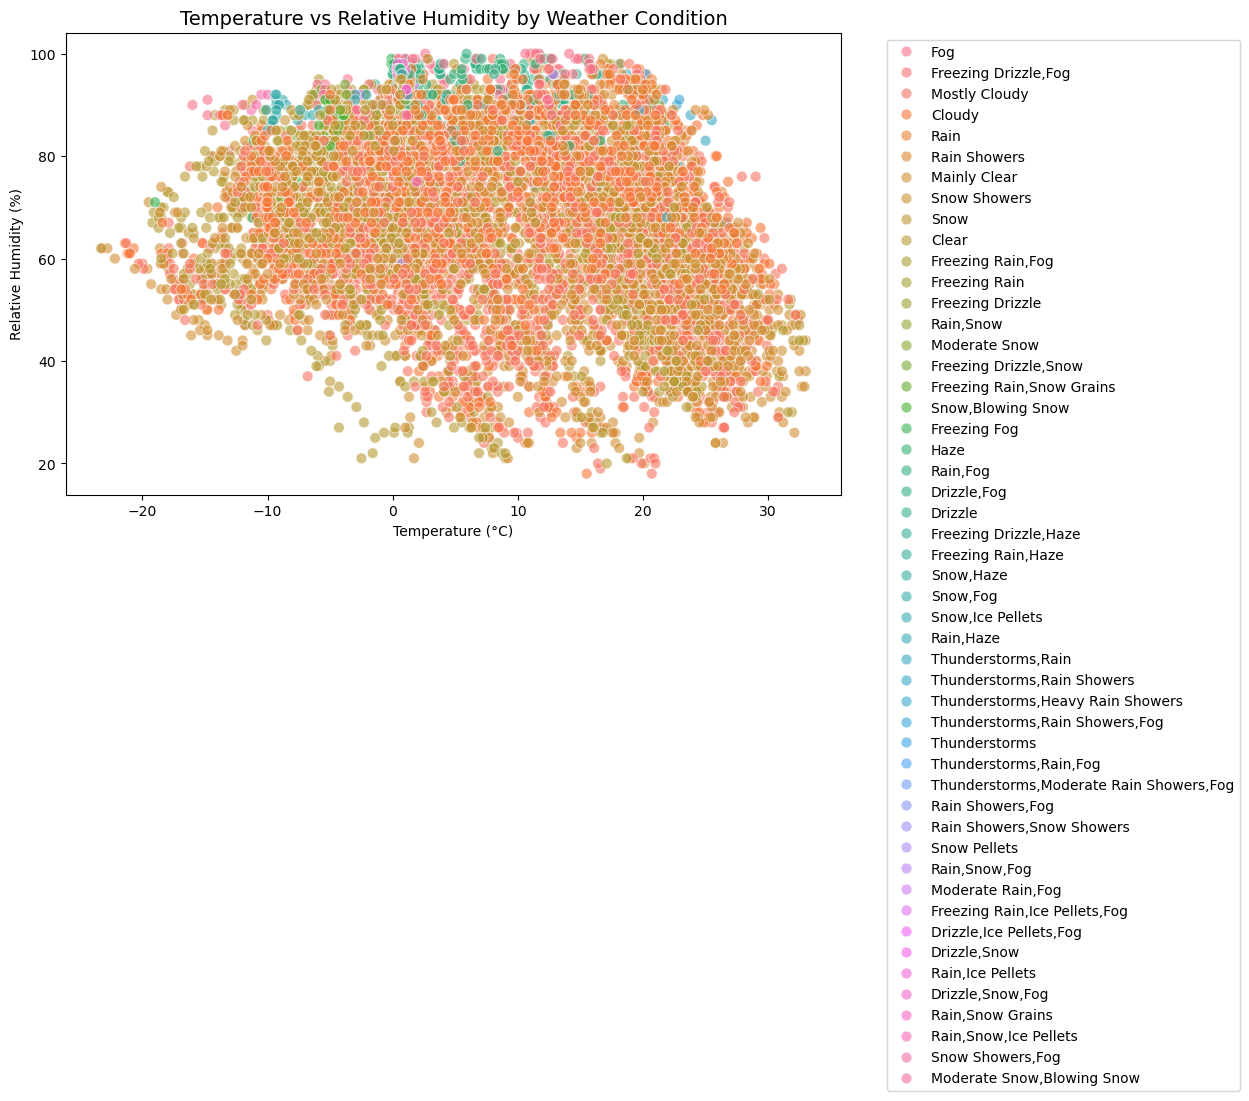

In [24]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Temp_C', y='Rel Hum_%', hue='Weather', data=data, alpha=0.6, s=60)
plt.title('Temperature vs Relative Humidity by Weather Condition', fontsize=14)
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


#### Wind Speed Distribution by Weather

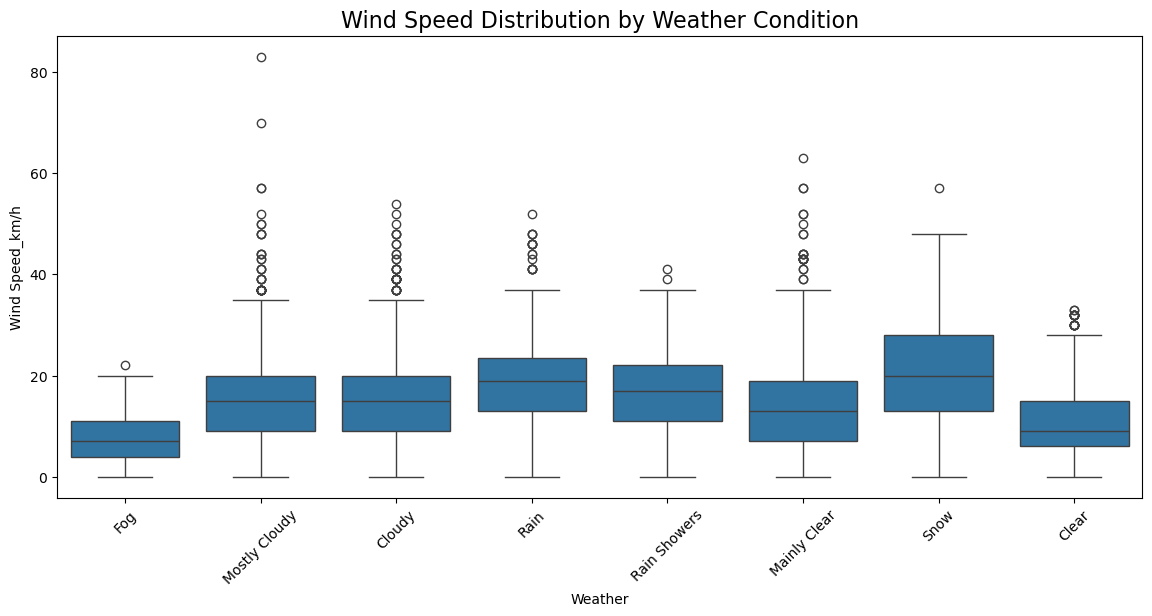

In [23]:
plt.figure(figsize=(14,6))
wind_dis = data[data['Weather'].isin(data['Weather'].value_counts().head(8).index)]
sns.boxplot(x='Weather', y='Wind Speed_km/h', data=wind_dis)
plt.xticks(rotation=45)
plt.title('Wind Speed Distribution by Weather Condition', fontsize=16)
plt.show()

#### Visibility analysis

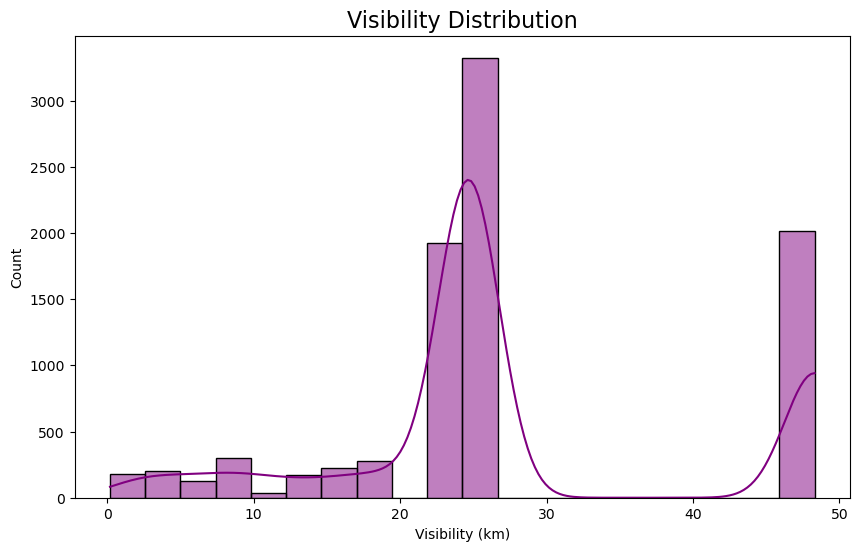

In [22]:
plt.figure(figsize=(10,6))
sns.histplot(data['Visibility_km'], bins=20, kde=True, color='purple')
plt.title('Visibility Distribution', fontsize=16)
plt.xlabel('Visibility (km)')
plt.show()

#### Correlation Matrix of Weather Parameters

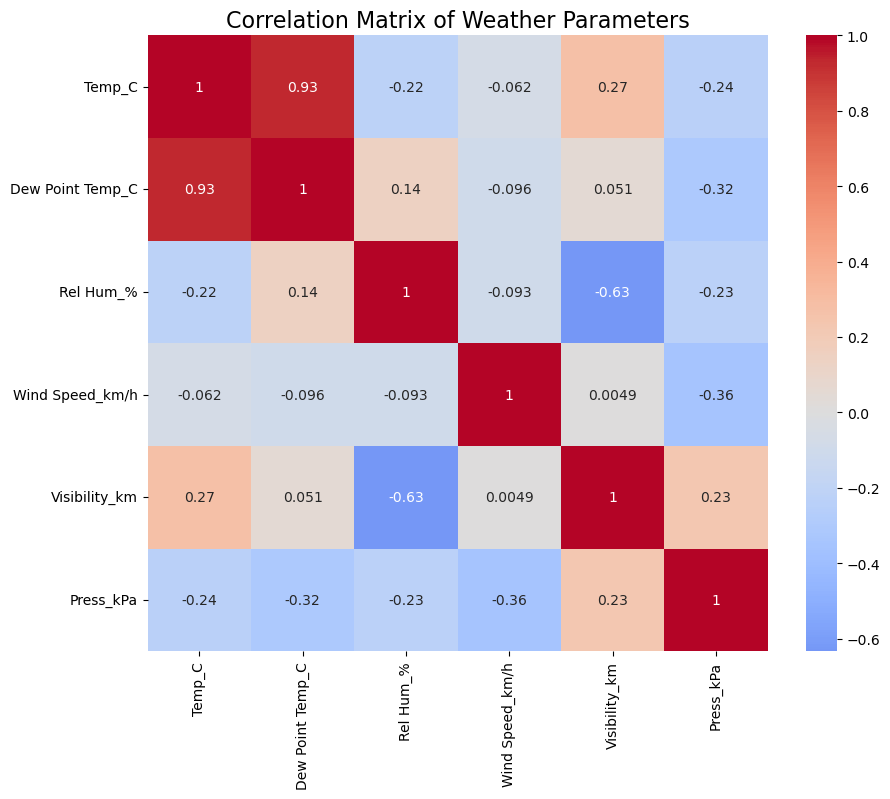

In [136]:
numeric_cols = ['Temp_C', 'Dew Point Temp_C', 'Rel Hum_%', 
                'Wind Speed_km/h', 'Visibility_km', 'Press_kPa']
plt.figure(figsize=(10,8))
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Weather Parameters', fontsize=16)
plt.show()

#### Extreme Temperature Analysis

In [20]:
print("=== EXTREME TEMPERATURE DAYS ===\n")

# Days with temperature > 30°C
hot_days = data[data['Temp_C'] > 30]
print(f"Days with Temperature > 30°C: {len(hot_days)} days")
print(hot_days[['Date/Time', 'Temp_C', 'Weather']].sort_values(by='Temp_C', ascending=False).head())

# Days with temperature < -15°C
cold_days = data[data['Temp_C'] < -15]
print(f"\nDays with Temperature < -15°C: {len(cold_days)} days")
print(cold_days[['Date/Time', 'Temp_C', 'Weather']].sort_values(by='Temp_C').head())

=== EXTREME TEMPERATURE DAYS ===

Days with Temperature > 30°C: 67 days
               Date/Time  Temp_C       Weather
4143 2012-06-21 15:00:00    33.0  Mainly Clear
4695 2012-07-14 15:00:00    33.0  Mainly Clear
4696 2012-07-14 16:00:00    32.9  Mainly Clear
5199 2012-08-04 15:00:00    32.8         Clear
4694 2012-07-14 14:00:00    32.7  Mainly Clear

Days with Temperature < -15°C: 130 days
              Date/Time  Temp_C        Weather
344 2012-01-15 08:00:00   -23.3          Clear
342 2012-01-15 06:00:00   -23.2  Mostly Cloudy
343 2012-01-15 07:00:00   -22.8   Mainly Clear
345 2012-01-15 09:00:00   -22.2   Mainly Clear
338 2012-01-15 02:00:00   -21.4         Cloudy


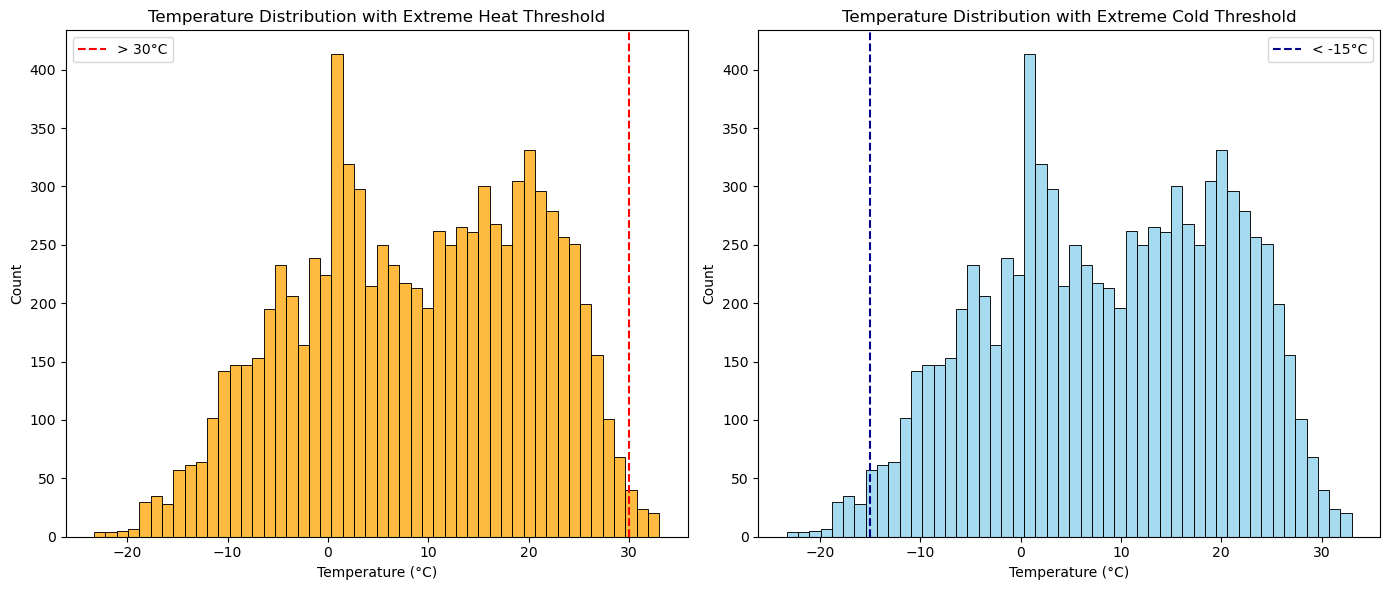

In [12]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(data['Temp_C'], bins=50, color='orange')
plt.axvline(30, color='red', linestyle='--', label='> 30°C')
plt.title('Temperature Distribution with Extreme Heat Threshold')
plt.xlabel('Temperature (°C)')
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(data['Temp_C'], bins=50, color='skyblue')
plt.axvline(-15, color='darkblue', linestyle='--', label='< -15°C')
plt.title('Temperature Distribution with Extreme Cold Threshold')
plt.xlabel('Temperature (°C)')
plt.legend()

plt.tight_layout()
plt.show()

#### Hours of Clear Weather per Month

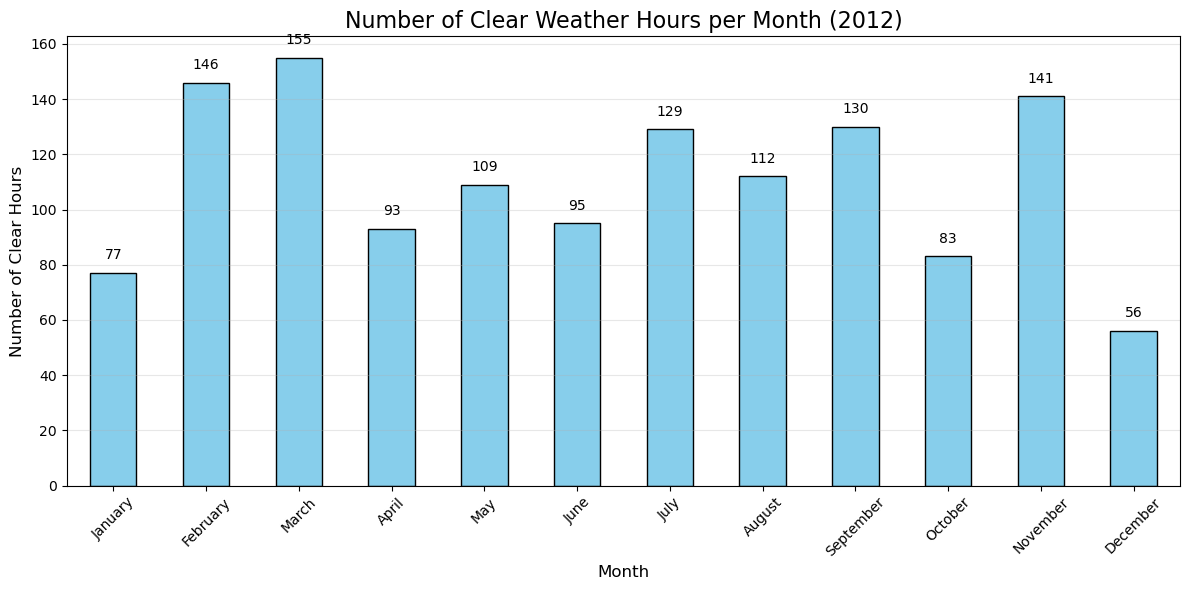

In [13]:
data['Hour'] = data['Date/Time'].dt.hour
clear_hours = data[data['Weather'] == 'Clear'].groupby('Month').size()

month_order = ['January', 'February', 'March', 'April', 'May', 'June','July', 'August', 'September', 'October', 'November', 'December']
clear_hours = clear_hours.reindex(month_order)

# Plot
plt.figure(figsize=(12, 6))
clear_hours.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Number of Clear Weather Hours per Month (2012)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Clear Hours', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(clear_hours):
    plt.text(i, v + 5, str(int(v)), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

#### Relationship between Pressure and Weather Conditions

C:\Users\USER\AppData\Local\Temp\ipykernel_10208\3497074429.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Weather', y='Press_kPa',


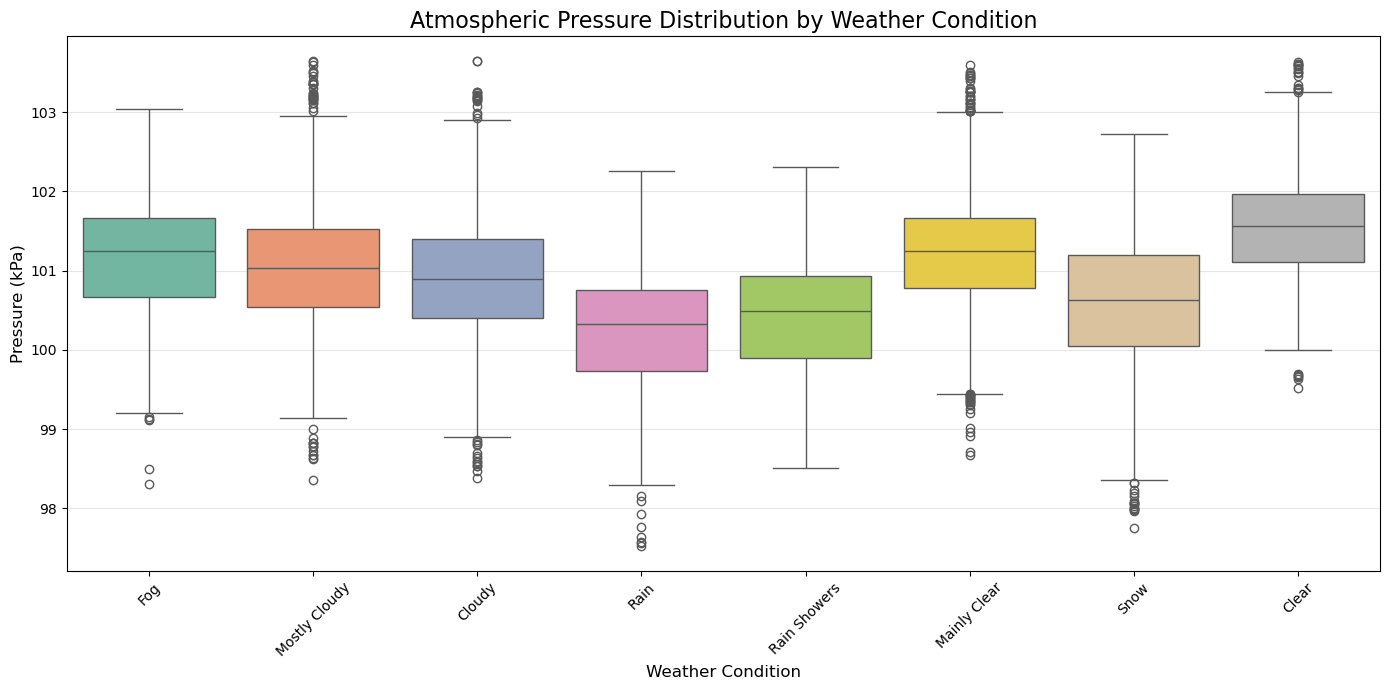

Average Pressure by Weather Condition:
Weather
Freezing Fog                     102.320000
Clear                            101.587443
Haze                             101.482500
Snow Showers,Fog                 101.292500
Mainly Clear                     101.248832
Fog                              101.184067
Rain Showers,Snow Showers        101.100000
Mostly Cloudy                    101.025288
Snow Showers                     100.963500
Freezing Rain,Ice Pellets,Fog    100.950000
Name: Press_kPa, dtype: float64


In [19]:
top_weather = data['Weather'].value_counts().head(8).index

plt.figure(figsize=(14, 7))
sns.boxplot(x='Weather', y='Press_kPa', 
            data=data[data['Weather'].isin(top_weather)],
            palette='Set2')
plt.title('Atmospheric Pressure Distribution by Weather Condition', fontsize=16)
plt.xlabel('Weather Condition', fontsize=12)
plt.ylabel('Pressure (kPa)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Mean pressure by weather
pressure_by_weather = data.groupby('Weather')['Press_kPa'].mean().sort_values(ascending=False)
print("Average Pressure by Weather Condition:")
print(pressure_by_weather.head(10))

#### Visibility vs Wind Speed (to understand fog formation)

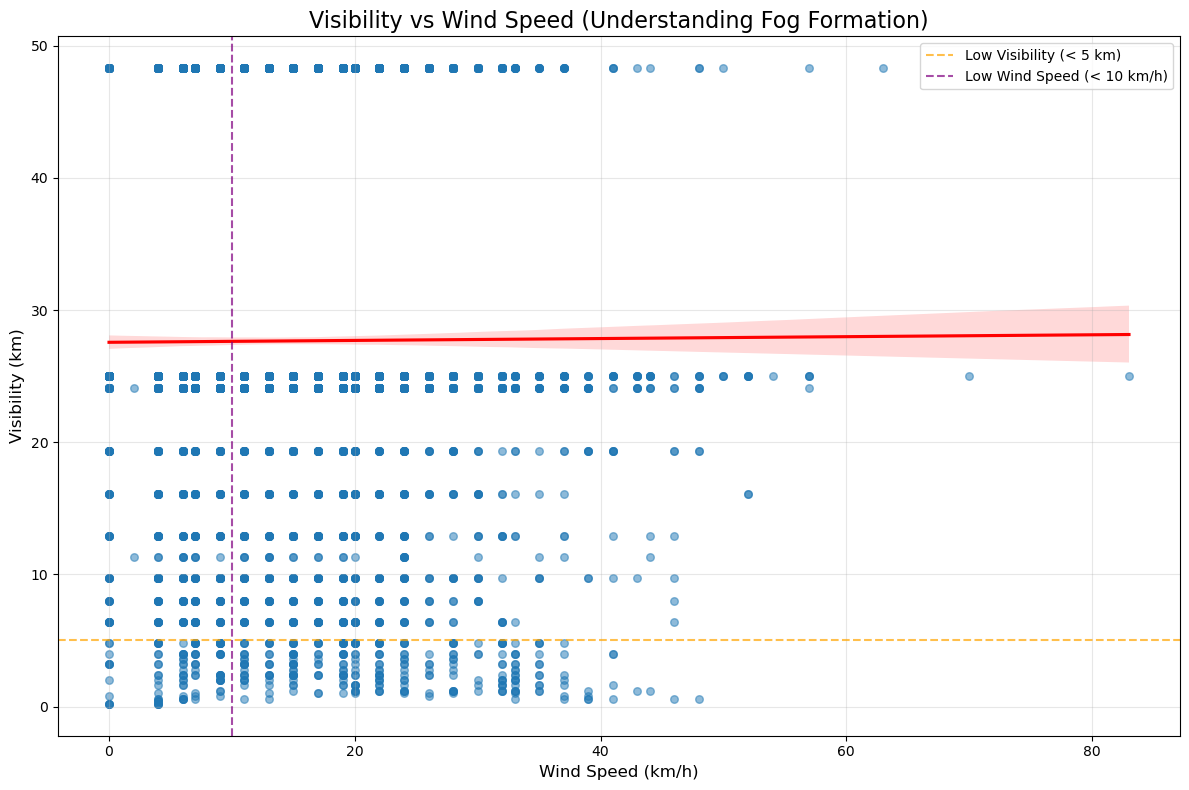

Correlation between Wind Speed and Visibility: 0.005


In [18]:
plt.figure(figsize=(12, 8))

# Scatter plot with regression line
sns.regplot(x='Wind Speed_km/h', y='Visibility_km',data=data,scatter_kws={'alpha':0.5, 's':30},line_kws={'color': 'red'})

plt.title('Visibility vs Wind Speed (Understanding Fog Formation)', fontsize=16)
plt.xlabel('Wind Speed (km/h)', fontsize=12)
plt.ylabel('Visibility (km)', fontsize=12)

# Highlight low visibility + low wind (typical fog condition)
plt.axhline(y=5, color='orange', linestyle='--', alpha=0.7, label='Low Visibility (< 5 km)')
plt.axvline(x=10, color='purple', linestyle='--', alpha=0.7, label='Low Wind Speed (< 10 km/h)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Statistical correlation
corr = data['Wind Speed_km/h'].corr(data['Visibility_km'])
print(f"Correlation between Wind Speed and Visibility: {corr:.3f}")

#### Combined Summary Table

In [16]:
summary = pd.DataFrame({
    'Metric': ['Hot Days (>30°C)', 'Cold Days (<-15°C)', 
               'Total Clear Hours', 'Avg Pressure (Clear)', 
               'Avg Pressure (Snow)'],
    'Value': [len(hot_days), len(cold_days), 
              clear_hours.sum(), 
              data[data['Weather']=='Clear']['Press_kPa'].mean(),
              data[data['Weather']=='Snow']['Press_kPa'].mean()]
})

print(summary)

                 Metric        Value
0      Hot Days (>30°C)    67.000000
1    Cold Days (<-15°C)   130.000000
2     Total Clear Hours  1326.000000
3  Avg Pressure (Clear)   101.587443
4   Avg Pressure (Snow)   100.536103


### Conclusion

The analysis reveals that 2012 experienced typical Canadian seasonal patterns with extreme cold in January (-23.3°C) and warm summers peaking at 33°C. Clear and Mostly Cloudy conditions dominated the year (over 47% of total observations). Visibility was strongly influenced by fog and snow events, while higher wind speeds were commonly associated with snow and rain showers.